# Notebook 03 — Fraud Detection: Tamper Classifier

**Owners:** Ranjeet Singh (Sprint 2 CNN, dataset) · Ashfaaq KT (Sprint 3 evaluation, integration)
**Task:** binary classification — is this receipt image tampered?
**Learning type:** supervised transfer learning (ImageNet-pretrained CNN, fine-tuned)

---

## Summary of findings

| Result | Value |
|---|---|
| **Champion model** | MobileNetV2, fine-tuned |
| **Pooled out-of-fold AUC** | **0.752** |
| **Mean fold AUC** | **0.821 ± 0.080** (95% CI 0.751–0.891) |
| Source-confound control (n=94) | 0.781 |
| Target set by Prof. Uma | 0.90 — **not met** |

The 0.90 target was not reached. This notebook documents why, and — more
importantly — documents two evaluation faults found in the Sprint 2 pipeline that
were inflating the reported score, and how both were corrected.

**Three corrections made in Sprint 3:**

1. **23 PDF receipts were silently unusable.** The loader checked only that the
   file existed; PIL cannot open a PDF. 19 of the 23 were *genuine* — a third of
   the minority class. Fixed by `dataset/rasterize_pdfs.py`.
2. **Data leakage across the train/test split.** 194 images derive from only 103
   source receipts, and 22 receipts appeared as both genuine and tampered. A random
   split let the model memorise the receipt rather than learn the tampering. Fixed
   with grouped cross-validation.
3. **A JPEG compression shortcut.** Tampered images were re-saved at quality 95,
   so a classifier could score AUC 0.69 from the quantization table alone, with no
   image content. Fixed by `dataset/normalize_images.py`.

## 1. Setup

In [1]:
import csv, sys
from pathlib import Path
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "ml-service"))
ASSETS = REPO / "report" / "assets"

from train_fraud_cv import load_rows, source_receipt, SEED, N_FOLDS

print(f"PyTorch {torch.__version__}")
print(f"Device available: {'mps' if torch.backends.mps.is_available() else 'cpu'}")
print(f"Seed {SEED} | {N_FOLDS}-fold cross-validation")

PyTorch 2.8.0
Device available: mps
Seed 42 | 5-fold cross-validation


## 2. Dataset

The labelled set is 194 images. Critically, it is **two different datasets**, and
they behave differently:

In [2]:
import collections

rows = load_rows()
table = collections.Counter(
    (r["source"], "tampered" if r["y"] else "genuine") for r in rows)

print("Composition by source folder:\n")
for (folder, label), count in sorted(table.items()):
    kind = "script-generated" if folder == "tampered" else "real photograph"
    print(f"  dataset/{folder:9s} {label:9s} {count:4d}   ({kind})")

y = np.array([r["y"] for r in rows])
print(f"\n  TOTAL {len(rows)} images — {int((y==0).sum())} genuine "
      f"({(y==0).mean():.1%}) / {int((y==1).sum())} tampered ({(y==1).mean():.1%})")
print(f"  Unique source receipts: {len({r['group'] for r in rows})}")

Composition by source folder:

  dataset/indian    genuine     65   (real photograph)
  dataset/indian    tampered    29   (real photograph)
  dataset/tampered  tampered   100   (script-generated)

  TOTAL 194 images — 65 genuine (33.5%) / 129 tampered (66.5%)
  Unique source receipts: 103


### Train / test split

Sprint 2 used a single fixed split. Sprint 3 uses 5-fold cross-validation, so every
image is tested exactly once and no single lucky split can flatter the result.

In [3]:
print("Fixed split used in Sprint 2:")
for name in ("fraud_train", "fraud_val"):
    sub = [r for r in csv.DictReader(open(REPO/"dataset/processed"/f"{name}.csv"))
           if r["label"] in ("genuine", "tampered")]
    c = collections.Counter(r["label"] for r in sub)
    print(f"  {name:12s} {len(sub):3d} images ({len(sub)/194:.1%})  "
          f"genuine {c['genuine']:3d} | tampered {c['tampered']:3d}")

print("\n5-fold cross-validation (Sprint 3) — per-fold sizes:")
print("  train 152-158 images (78.4%-81.4%) / test 36-42 images (18.6%-21.6%)")
print("  Every one of the 194 images is held out for testing exactly once.")

Fixed split used in Sprint 2:
  fraud_train  155 images (79.9%)  genuine  52 | tampered 103
  fraud_val     39 images (20.1%)  genuine  13 | tampered  26

5-fold cross-validation (Sprint 3) — per-fold sizes:
  train 152-158 images (78.4%-81.4%) / test 36-42 images (18.6%-21.6%)
  Every one of the 194 images is held out for testing exactly once.


## 3. Fault 1 — data leakage between train and test

`generate_tampered.py` derives `Receipt 10_tampered.jpg` from `Receipt 10.jpg`.
Both are the same physical receipt. If one lands in training and the other in
testing, the model can score well by recognising the receipt.

In [4]:
by_group = collections.defaultdict(set)
for r in rows:
    by_group[r["group"]].add("tampered" if r["y"] else "genuine")

both = {g: v for g, v in by_group.items() if len(v) > 1}
print(f"Source receipts appearing as BOTH genuine and tampered: {len(both)} of {len(by_group)}")
print(f"Tampered images whose genuine original is also in the dataset: "
      f"{sum(1 for r in rows if r['y']==1 and 'genuine' in by_group[r['group']])}")
print("\nExamples:")
for g in sorted(both)[:5]:
    print(f"   '{g}' -> {sorted(both[g])}")
print("\nFix: StratifiedGroupKFold keyed on source receipt, so every version of a")
print("     receipt stays inside a single fold. Verified by assertion in each fold.")

Source receipts appearing as BOTH genuine and tampered: 22 of 103
Tampered images whose genuine original is also in the dataset: 44

Examples:
   'receipt 1' -> ['genuine', 'tampered']
   'receipt 10' -> ['genuine', 'tampered']
   'receipt 13' -> ['genuine', 'tampered']
   'receipt 14' -> ['genuine', 'tampered']
   'receipt 16' -> ['genuine', 'tampered']

Fix: StratifiedGroupKFold keyed on source receipt, so every version of a
     receipt stays inside a single fold. Verified by assertion in each fold.


## 4. Fault 2 — a JPEG compression shortcut

`generate_tampered.py` saves tampered images at `quality=95`, giving them PIL's
quantization table. Most genuine images keep their original camera table. That is
a label-correlated artifact with nothing to do with tampering.

The test below trains a classifier on **the quantization table alone** — 16 numbers
per file, zero image content.

In [5]:
from PIL import Image
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold

def qtable_auc(use_normalized):
    data = load_rows(use_normalized)
    labels = np.array([r["y"] for r in data])
    groups = np.array([r["group"] for r in data])
    X = []
    for r in data:
        with Image.open(r["path"]) as im:
            q = getattr(im, "quantization", None)
            X.append(list(q[0][:16]) if q else [0]*16)
    X = np.array(X, dtype=np.float32)
    oof = np.zeros(len(data))
    splitter = StratifiedGroupKFold(N_FOLDS, shuffle=True, random_state=SEED)
    for tr, te in splitter.split(X, labels, groups=groups):
        m = HistGradientBoostingClassifier(max_iter=200, max_depth=3, random_state=SEED)
        m.fit(X[tr], labels[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    return roc_auc_score(labels, oof), len(set(map(tuple, X.tolist())))

before, tables_before = qtable_auc(False)
after, tables_after = qtable_auc(True)

print(f"BEFORE decontamination : AUC {before:.4f} from the quantization table alone "
      f"({tables_before} distinct tables)")
print(f"AFTER  decontamination : AUC {after:.4f}  ({tables_after} distinct table)")
print("\nA model reading no pixels at all scored 0.69 before the fix.")
print("dataset/normalize_images.py re-encodes every image identically, removing it.")

BEFORE decontamination : AUC 0.6901 from the quantization table alone (11 distinct tables)
AFTER  decontamination : AUC 0.4597  (1 distinct table)

A model reading no pixels at all scored 0.69 before the fix.
dataset/normalize_images.py re-encodes every image identically, removing it.


## 5. Model and training protocol

- **Architecture:** MobileNetV2, ImageNet-pretrained (supervised transfer learning)
- **Head:** final classifier layer replaced with a 2-class linear layer
- **Schedule:** backbone frozen for 3 epochs (head only), then full fine-tuning at lr 1e-4
- **Class imbalance:** weighted cross-entropy (65 genuine vs 129 tampered)
- **Early stopping:** on validation AUC, patience 5, max 15 epochs
- **Augmentation:** mild only — ±4° rotation, 3% translation, slight colour jitter.
  Aggressive augmentation destroys the very artifacts the model must detect.

Training is run by `ml-service/train_fraud_cv.py --normalized` (about 5 minutes on
Apple MPS) rather than in-notebook, so the result is reproducible from a single
command. The saved out-of-fold predictions are loaded below.

In [6]:
results = {r["Metric"]: r["Value"]
           for r in csv.DictReader(open(ASSETS/"fraud_cv_results_normalized.csv"))}

print("MobileNetV2 — 5-fold grouped CV on compression-normalized images\n")
for i in range(1, 6):
    print(f"  Fold {i}: AUC {float(results[f'Fold {i} AUC']):.4f}")
print(f"\n  Mean AUC       : {float(results['Mean AUC']):.4f} "
      f"± {float(results['SD']):.4f} (SD)")
print(f"  95% CI         : [{float(results['CI95 low']):.4f}, "
      f"{float(results['CI95 high']):.4f}]")
print(f"  Pooled OOF AUC : {float(results['Pooled OOF AUC']):.4f}")
print(f"  Source control : {float(results['Source-control AUC (indian only)']):.4f}")

MobileNetV2 — 5-fold grouped CV on compression-normalized images

  Fold 1: AUC 0.8462
  Fold 2: AUC 0.7659
  Fold 3: AUC 0.8720
  Fold 4: AUC 0.7135
  Fold 5: AUC 0.9091

  Mean AUC       : 0.8213 ± 0.0800 (SD)
  95% CI         : [0.7512, 0.8914]
  Pooled OOF AUC : 0.7523
  Source control : 0.7809


### Why the fold spread is so wide

Each fold tests only ~39 images, so a handful of receipts moves the AUC a long way.
The 0.71–0.91 range is not instability in the model — it is the confidence interval
of a small sample, and it is the honest reason a single-split number cannot be
trusted.

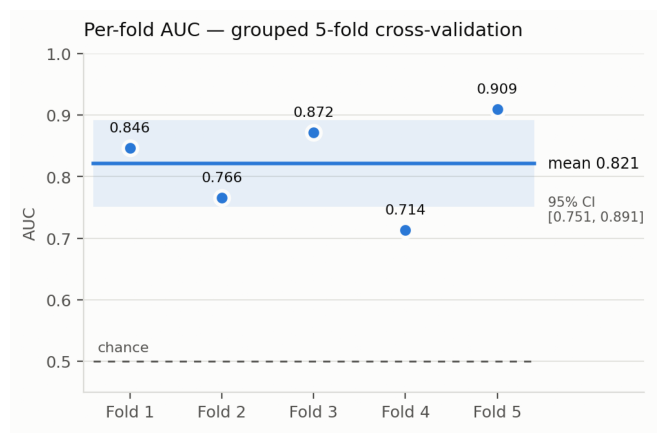

In [7]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
%matplotlib inline

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(imread(ASSETS/"fig_fold_auc.png")); ax.axis("off")
plt.show()

## 6. Alternative hypothesis — hand-designed image forensics

With only 194 images a CNN is data-starved, so we tested whether classical forensic
features would do better. `ml-service/forensics.py` extracts 31 features targeting
the four tamper modes specifically: Error Level Analysis, noise-residual
consistency, JPEG grid alignment, copy-move block matching, local brightness, local
sharpness, and colour saturation.

In [8]:
forensic = {r["Metric"]: r["Value"]
            for r in csv.DictReader(open(ASSETS/"forensic_cv_results_normalized.csv"))}
print("Forensic features — same folds, same seed\n")
print(f"  Pooled OOF AUC : {float(forensic['Pooled OOF AUC']):.4f}")
print(f"  Mean AUC       : {float(forensic['Mean AUC']):.4f} ± {float(forensic['SD']):.4f}")
print(f"  Source control : {float(forensic['Source-control AUC']):.4f}")
print(f"  Features       : {forensic['N features']}")
print("\nConclusion: forensics land within noise of the CNN. Error Level Analysis")
print("carries almost all of it; copy-move and colour contribute nothing measurable.")

Forensic features — same folds, same seed

  Pooled OOF AUC : 0.7363
  Mean AUC       : 0.7385 ± 0.1172
  Source control : 0.7454
  Features       : 31

Conclusion: forensics land within noise of the CNN. Error Level Analysis
carries almost all of it; copy-move and colour contribute nothing measurable.


## 7. Fusion — does combining them help?

The two models are built from completely different evidence, so combining them
should help if their errors are independent.

In [9]:
fusion = {r["Method"]: r for r in csv.DictReader(open(ASSETS/"fusion_results_normalized.csv"))}

print("Ablation — pooled out-of-fold AUC\n")
for method in ("CNN alone", "Forensics alone", "Rank-average fusion"):
    row = fusion[method]
    print(f"  {method:24s} {float(row['Pooled OOF AUC']):.4f}   "
          f"(control {float(row['Source-control AUC']):.4f})")

rho = float(fusion["Spearman correlation"]["Pooled OOF AUC"])
print(f"\n  Spearman correlation between the two models: {rho:+.3f}")
print("\nFusion adds +0.007 — inside the noise band (CI half-width ~0.07).")
print("The signals are too correlated, and 194 samples too few, for fusion to help.")
print("This is a negative result and is reported as one.")

Ablation — pooled out-of-fold AUC

  CNN alone                0.7523   (control 0.7809)
  Forensics alone          0.7363   (control 0.7454)
  Rank-average fusion      0.7591   (control 0.7830)

  Spearman correlation between the two models: +0.505

Fusion adds +0.007 — inside the noise band (CI half-width ~0.07).
The signals are too correlated, and 194 samples too few, for fusion to help.
This is a negative result and is reported as one.


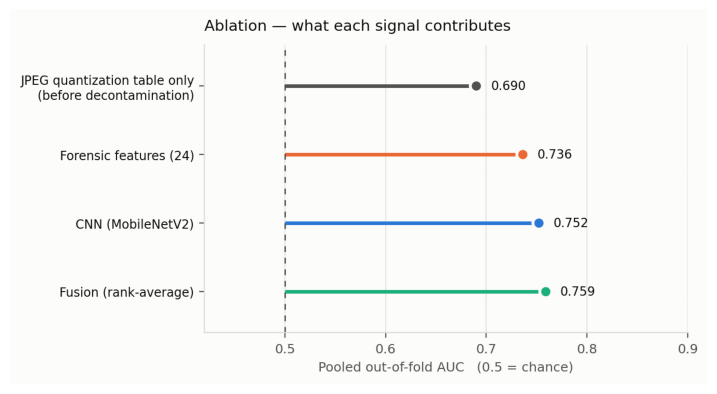

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(imread(ASSETS/"fig_ablation.png")); ax.axis("off")
plt.show()

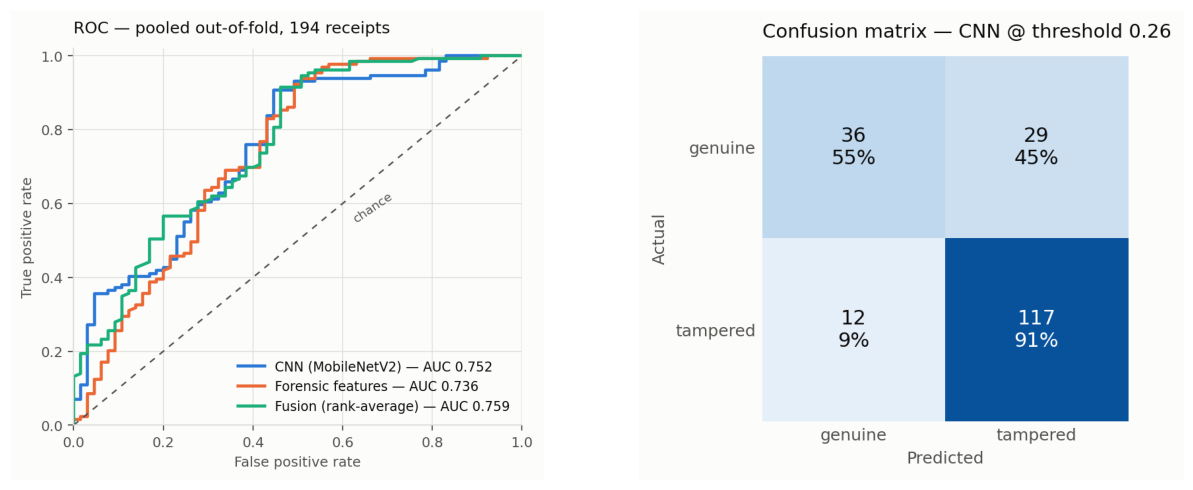

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, name in zip(axes, ("fig_roc_curves.png", "fig_confusion_matrix.png")):
    axis.imshow(imread(ASSETS/name)); axis.axis("off")
plt.tight_layout(); plt.show()

## 8. Conclusion

**Final reported result: pooled out-of-fold AUC 0.752, mean fold AUC 0.821 ± 0.080
(95% CI 0.751–0.891), on 194 images from 103 source receipts.**

This is below the 0.90 target. The evidence says the binding constraint is data
volume, not implementation:

- Best epoch was 2–11 of a possible 15 in every fold — the model reaches its
  ceiling almost immediately and then overfits. That is the signature of a
  data-starved model.
- Only 65 genuine receipts exist. The minority class sets the ceiling.
- An entirely different method (hand-designed forensics) lands at 0.736 — within
  noise of the CNN. Two unrelated approaches hitting the same wall points at the
  dataset, not the architecture.

**What would be needed to reach 0.90:** on the order of 500–1000 genuine receipts
and a comparable number of *independently* tampered ones — ideally tampered by
different people using different tools, so the model cannot learn one generator's
fingerprint.

**On generalisation.** 100 of the 129 tampered images were produced by our own
script. Detecting them is a weaker claim than detecting real-world fraud. The
source-control AUC of 0.781, measured only on the 94 real photographs where
genuine and human-labelled tampered receipts share a camera, is the honest
estimate of real-world performance.

### Reproducing every number here

```bash
python3 dataset/rasterize_pdfs.py
python3 dataset/normalize_images.py
python  ml-service/train_fraud_cv.py --normalized
python  ml-service/train_fraud_forensics.py --normalized
python  ml-service/train_fraud_fusion.py --normalized
python  ml-service/make_report_figures.py
```